In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pooch
from IPython.display import display, HTML
import plotly.express as px
from fair import FAIR
from fair.interface import fill, initialise
from fair.io import read_properties

/Users/susierwu/miniconda3/envs/ar6/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# A. first run FAIR model, as output parameters of fair will be used as input for calculating d-GWP

## 1. Create FaIR instance

To reproduce an AR6-like run, we want to allow methane lifetime to be affected by all its relevant chemical precursors (NOx, VOCs, etc) so we set the `ch4_method` flag to `Thornhill2021` (see https://docs.fairmodel.net/en/latest/api_reference.html#fair.FAIR for all of the options for initialising `FAIR`).

In [2]:
f = FAIR(ch4_method="Thornhill2021")

## 2. Define time horizon

A lot of analysis uses 2100 as the time horizon, but 2300 is an interesting end point to see the effects of long-term climate change. We'll set 2300 as the last time bound, so the last emissions time point is 2299.5. We could even run to 2500, as the scenarios are defined that far.

In [3]:
f.define_time(1750, 2500, 1)  # start=1750(baselinE), end=2300, step

## 3. Define scenarios

Since the eight tier 1 & tier 2 SSPs are shipped with RCMIP, and they are quite familiar, we'll use these scenarios. We'll use the `fill_from_rcmip()` function from FaIR, so these have to use the same scenario names that appear in the RCMIP database.

In [4]:
#scenarios = ["ssp119", "ssp126", "ssp245",  "ssp585"]
scenarios = ["ssp119", "ssp126", "ssp245", "ssp370", "ssp434", "ssp460", "ssp585"]
#scenarios = ["ssp119", "ssp126", "ssp245", "ssp370", "ssp434", "ssp460", "ssp534-over", "ssp585"]

In [5]:
f.define_scenarios(scenarios)

## 4. Define configs

In [6]:
fair_params_1_2_0_obj = pooch.retrieve(
    url = 'https://zenodo.org/record/8399112/files/calibrated_constrained_parameters.csv',
    known_hash = 'md5:de3b83432b9d071efdd1427ad31e9076',
)

In [7]:
df_configs = pd.read_csv(fair_params_1_2_0_obj, index_col=0)
configs = df_configs.index  # this is used as a label for the "config" axis
f.define_configs(configs)

df_configs.head()

## 5. Define species and properties

We will use FaIR's default list of 63 species. They are often run with default properties that are included in the model code. However, as part of the v1.1 calibration, some defaults are modified, such as the sensitivity of chemical precursors to methane lifetime. Rather than manually overriding this by setting `species_configs`, it is cleaner to modify the defaults in the CSV file that is read in to define the `species` and `properties`. 

In fact, as this only reads in and defines `species` and `properties` (not `species_configs`), the default (no `filename`) argument could be used here, but it is good practice in my opinion to put species, properties and configs in the same file, and to use the same file to read in `properties` and `species_configs`.

If you're following along at home, feel free to insert a new cell after this one and inspect what the `species` and `properties` actually are.

In [8]:
#https://github.com/OMS-NetZero/FAIR/blob/master/examples/data/species_configs_properties_calibration1.2.0.csv 
#saved to 'data/ ... 
species, properties = read_properties(filename='data/species_configs_properties_calibration1.2.0.csv')
f.define_species(species, properties)

## 6. Modify run options

Not necessary, as we made all of our choices on initialisation (step 1).

## 7. Create input and output xarrays

If this runs without error, the problem is consistently and completely set up: we then just need to add data.

In [9]:
f.allocate()

## 8. Fill in data

### 8a. emissions, solar forcing, and volcanic forcing

We can use the convenience function `fill_from_rcmip()` to fill in the emissions. Remember that not all `species` are things that take emissions, so if you see NaNs below, don't panic.

In [10]:
f.fill_from_rcmip()

In [11]:
print(f.concentration.coords["specie"].values)

['CO2 FFI' 'CO2 AFOLU' 'CO2' 'CH4' 'N2O' 'Sulfur' 'BC' 'OC' 'NH3' 'NOx'
 'VOC' 'CO' 'CFC-11' 'CFC-12' 'CFC-113' 'CFC-114' 'CFC-115' 'HCFC-22'
 'HCFC-141b' 'HCFC-142b' 'CCl4' 'CHCl3' 'CH2Cl2' 'CH3Cl' 'CH3CCl3' 'CH3Br'
 'Halon-1202' 'Halon-1211' 'Halon-1301' 'Halon-2402' 'CF4' 'C2F6' 'C3F8'
 'c-C4F8' 'C4F10' 'C5F12' 'C6F14' 'C7F16' 'C8F18' 'NF3' 'SF6' 'SO2F2'
 'HFC-125' 'HFC-134a' 'HFC-143a' 'HFC-152a' 'HFC-227ea' 'HFC-23'
 'HFC-236fa' 'HFC-245fa' 'HFC-32' 'HFC-365mfc' 'HFC-4310mee'
 'NOx aviation' 'Solar' 'Volcanic' 'Aerosol-radiation interactions'
 'Aerosol-cloud interactions' 'Ozone' 'Contrails'
 'Light absorbing particles on snow and ice' 'Stratospheric water vapour'
 'Land use' 'Equivalent effective stratospheric chlorine']


In [12]:
print(f.emissions.coords["specie"].values)

['CO2 FFI' 'CO2 AFOLU' 'CO2' 'CH4' 'N2O' 'Sulfur' 'BC' 'OC' 'NH3' 'NOx'
 'VOC' 'CO' 'CFC-11' 'CFC-12' 'CFC-113' 'CFC-114' 'CFC-115' 'HCFC-22'
 'HCFC-141b' 'HCFC-142b' 'CCl4' 'CHCl3' 'CH2Cl2' 'CH3Cl' 'CH3CCl3' 'CH3Br'
 'Halon-1202' 'Halon-1211' 'Halon-1301' 'Halon-2402' 'CF4' 'C2F6' 'C3F8'
 'c-C4F8' 'C4F10' 'C5F12' 'C6F14' 'C7F16' 'C8F18' 'NF3' 'SF6' 'SO2F2'
 'HFC-125' 'HFC-134a' 'HFC-143a' 'HFC-152a' 'HFC-227ea' 'HFC-23'
 'HFC-236fa' 'HFC-245fa' 'HFC-32' 'HFC-365mfc' 'HFC-4310mee'
 'NOx aviation' 'Solar' 'Volcanic' 'Aerosol-radiation interactions'
 'Aerosol-cloud interactions' 'Ozone' 'Contrails'
 'Light absorbing particles on snow and ice' 'Stratospheric water vapour'
 'Land use' 'Equivalent effective stratospheric chlorine']


f.emissions

f.timepoints  #it is float, changed in module to select correct year modeling decay side

There is an issue with the RCMIP NOx emissions; the units are different for biomass burning emissions (Tg NO/yr) to the other emissions from fossil fuels, industry and agriculture (Tg NO2/yr). v1.1 of the calibration uses the corrected NOx emissions expressed in Tg NO2/yr, so we also have to correct them in FaIR for consistency.

We download the RCMIP emissions file, and pull out the relevant sectors, update the unit, and finally override the correct entry of `f.emissions`.

Notes on the below:

- 46.006 is the molecular weight of NO2 (g/mol).
- 30.006 is the molecular weight of NO (g/mol).
- The final `[:550, None]` is to transfer the data coming in from RCMIP (dimension (750,), a timeseries of annual emissions) into the correct shape for our problem (550, 1001). Since we are looping over the `scenario` dimension and selecting it, and we are selecting NOx from the `species` dimension, these axes are collapsed and we're left with (`timepoints`, `configs`). The RCMIP data starts in 1750 as does our emissions data; if there is a mismatch in the start date, it would be necessary to select the correct slice from the RCMIP `DataFrame` that is loaded in. For a reminder of the dimensioning in FaIR 2.1, see https://docs.fairmodel.net/en/latest/intro.html#dimensionality.

In [13]:
### now with new start / end year 1750 - 2500, we have total 750 shape 
rcmip_emissions_file = pooch.retrieve(
    url="doi:10.5281/zenodo.4589756/rcmip-emissions-annual-means-v5-1-0.csv",
    known_hash="md5:4044106f55ca65b094670e7577eaf9b3",
)
df_emis = pd.read_csv(rcmip_emissions_file)
gfed_sectors = [
    "Emissions|NOx|MAGICC AFOLU|Agricultural Waste Burning",
    "Emissions|NOx|MAGICC AFOLU|Forest Burning",
    "Emissions|NOx|MAGICC AFOLU|Grassland Burning",
    "Emissions|NOx|MAGICC AFOLU|Peat Burning",
]
for scenario in scenarios:
    f.emissions.loc[dict(specie="NOx", scenario=scenario)] = (
        df_emis.loc[
            (df_emis["Scenario"] == scenario)
            & (df_emis["Region"] == "World")
            & (df_emis["Variable"].isin(gfed_sectors)),
            #"2000":"2500",       #change back to 2300 as default
            "1750":"2500", 
        ]
        .interpolate(axis=1)
        .values.squeeze()
        .sum(axis=0)
        * 46.006
        / 30.006
        + df_emis.loc[
            (df_emis["Scenario"] == scenario)
            & (df_emis["Region"] == "World")
            & (df_emis["Variable"] == "Emissions|NOx|MAGICC AFOLU|Agriculture"),
            #"2000":"2500",
            "1750":"2500", 
        ]
        .interpolate(axis=1)
        .values.squeeze()
        + df_emis.loc[
            (df_emis["Scenario"] == scenario)
            & (df_emis["Region"] == "World")
            & (df_emis["Variable"] == "Emissions|NOx|MAGICC Fossil and Industrial"),
           # "2000":"2500",
            "1750":"2500", 
        ]
        .interpolate(axis=1)
        .values.squeeze()
    )[:750, None]  # 550 if ending year 2300 and starting 1750,  500 if 2000 to 2500

Now we fetch and fill in the solar and volcanic forcing. As these are forcing-driven time series, if we want to vary the uncertainties in the forcing, this has to happen before FaIR is run (see https://github.com/OMS-NetZero/FAIR/issues/126).

In [14]:
solar_obj = pooch.retrieve(
    url = 'https://raw.githubusercontent.com/chrisroadmap/fair-add-hfc/main/data/solar_erf_timebounds.csv',
    known_hash = 'md5:98f6f4c5309d848fea89803683441acf',
)

In [15]:
volcanic_obj = pooch.retrieve(
    url = 'https://raw.githubusercontent.com/chrisroadmap/fair-calibrate/main/data/forcing/volcanic_ERF_1750-2101_timebounds.csv',
    known_hash = 'md5:c0801f80f70195eb9567dbd70359219d',
)

#### <font color = "red">df_solar only has data 1750 - up tp 2300 </font>

In [16]:
df_solar = pd.read_csv(solar_obj, index_col="year")
df_volcanic = pd.read_csv(volcanic_obj)

Remembering that everything that is not emissions is on `timebounds`, there is always one more `timebounds` than `timepoints`, so we define arrays of length 551 (1750 to 2300, inclusive).

Volcanic forcing is given monthly, so we average the 12 previous months for each `timebounds` volcanic forcing.

Volcanic forcing here follows the CMIP6 ScenarioMIP convention of a 10 year ramp down to zero from the last year of data (here 2019). Again a little bit of ninja skill with indexing is needed.

In [17]:
l = 751
# since we change ending year to 2500, AND starting year to 2000 here we need new array.dim to (751,1001)
# with now change to 1750 to 2500, l = (2500−1750)+1=751
solar_forcing = np.zeros(l)
volcanic_forcing = np.zeros(l)

# changed to n_vols so doesn't matter start/end year 
n_volc = len(df_volcanic.erf.values)
volcanic_forcing[:n_volc] = df_volcanic.erf.values

#volcanic_forcing[:352] = df_volcanic.erf.values
# now should be 2300-1750+1 = 551   # was 301
solar_forcing[:551] = df_solar["erf"].loc[1750:2300].values  # change to 1750 

# this doens't change  # 2020-1750+1 = 271
trend_shape = np.ones(l)
trend_shape[:271] = np.linspace(0, 1, 271) 

We then use our calibrated, constrained ensemble to individually scale the volcanic forcing time series, and the solar amplitude and trend:

In [18]:
fill(
    f.forcing,
    volcanic_forcing[:, None, None] * df_configs["fscale_Volcanic"].values.squeeze(),
    specie="Volcanic",
)
fill(
    f.forcing,
    solar_forcing[:, None, None] * df_configs["fscale_solar_amplitude"].values.squeeze()
    + trend_shape[:, None, None] * df_configs["fscale_solar_trend"].values.squeeze(),
    specie="Solar",
)

### 8b. Fill in climate_configs

This is relatively straightforward from the calibrated, constrained dataset.

In [19]:
fill(f.climate_configs["ocean_heat_capacity"], df_configs.loc[:, "clim_c1":"clim_c3"].values)
fill(
    f.climate_configs["ocean_heat_transfer"],
    df_configs.loc[:, "clim_kappa1":"clim_kappa3"].values,
)
fill(f.climate_configs["deep_ocean_efficacy"], df_configs["clim_epsilon"].values.squeeze())
fill(f.climate_configs["gamma_autocorrelation"], df_configs["clim_gamma"].values.squeeze())
fill(f.climate_configs["sigma_eta"], df_configs["clim_sigma_eta"].values.squeeze())
fill(f.climate_configs["sigma_xi"], df_configs["clim_sigma_xi"].values.squeeze())
fill(f.climate_configs["seed"], df_configs["seed"])
fill(f.climate_configs["stochastic_run"], True)
fill(f.climate_configs["use_seed"], True)
fill(f.climate_configs["forcing_4co2"], df_configs["clim_F_4xCO2"])

### 8c. Fill in species_configs

Firstly we want to get the defaults from our new species/properties/configs file

In [20]:
f.fill_species_configs(filename='data/species_configs_properties_calibration1.2.0.csv')

Then, we overwrite the `species_configs` that are varies as part of the probablistic sampling. This makes heavy use of the `fill()` convenience function.

In [21]:
# carbon cycle
fill(f.species_configs["iirf_0"], df_configs["cc_r0"].values.squeeze(), specie="CO2")
fill(f.species_configs["iirf_airborne"], df_configs["cc_rA"].values.squeeze(), specie="CO2")
fill(f.species_configs["iirf_uptake"], df_configs["cc_rU"].values.squeeze(), specie="CO2")
fill(f.species_configs["iirf_temperature"], df_configs["cc_rT"].values.squeeze(), specie="CO2")

# aerosol indirect
fill(f.species_configs["aci_scale"], df_configs["aci_beta"].values.squeeze())
fill(f.species_configs["aci_shape"], df_configs["aci_shape_so2"].values.squeeze(), specie="Sulfur")
fill(f.species_configs["aci_shape"], df_configs["aci_shape_bc"].values.squeeze(), specie="BC")
fill(f.species_configs["aci_shape"], df_configs["aci_shape_oc"].values.squeeze(), specie="OC")

# aerosol direct
for specie in [
    "BC", 
    "CH4", 
    "N2O",
    "NH3", 
    "NOx",
    "OC", 
    "Sulfur", 
    "VOC",
    "Equivalent effective stratospheric chlorine"
]:
    fill(f.species_configs["erfari_radiative_efficiency"], df_configs[f"ari_{specie}"], specie=specie)

# forcing scaling
for specie in [
    "CO2", 
    "CH4", 
    "N2O", 
    "Stratospheric water vapour",
    "Contrails", 
    "Light absorbing particles on snow and ice", 
    "Land use"
]:
    fill(f.species_configs["forcing_scale"], df_configs[f"fscale_{specie}"].values.squeeze(), specie=specie)
# the halogenated gases all take the same scale factor
for specie in [
    "CFC-11",
    "CFC-12",
    "CFC-113",
    "CFC-114",
    "CFC-115",
    "HCFC-22",
    "HCFC-141b",
    "HCFC-142b",
    "CCl4",
    "CHCl3",
    "CH2Cl2",
    "CH3Cl",
    "CH3CCl3",
    "CH3Br",
    "Halon-1211",
    "Halon-1301",
    "Halon-2402",
    "CF4",
    "C2F6",
    "C3F8",
    "c-C4F8",
    "C4F10",
    "C5F12",
    "C6F14",
    "C7F16",
    "C8F18",
    "NF3",
    "SF6",
    "SO2F2",
    "HFC-125",
    "HFC-134a",
    "HFC-143a",
    "HFC-152a",
    "HFC-227ea",
    "HFC-23",
    "HFC-236fa",
    "HFC-245fa",
    "HFC-32",
    "HFC-365mfc",
    "HFC-4310mee",
]:
    fill(f.species_configs["forcing_scale"], df_configs["fscale_minorGHG"].values.squeeze(), specie=specie)

# ozone
for specie in ["CH4", "N2O", "Equivalent effective stratospheric chlorine", "CO", "VOC", "NOx"]:
    fill(f.species_configs["ozone_radiative_efficiency"], df_configs[f"o3_{specie}"], specie=specie)

# initial value of CO2 concentration (but not baseline for forcing calculations)
fill(
    f.species_configs["baseline_concentration"], 
    df_configs["cc_co2_concentration_1750"].values.squeeze(), 
    specie="CO2"
)

### 8d. Initial conditions

It's important these are defined, as they are NaN by default, and it's likely you'll run into problems.

In [22]:
initialise(f.concentration, f.species_configs["baseline_concentration"])
initialise(f.forcing, 0)
initialise(f.temperature, 0)
initialise(f.cumulative_emissions, 0)
initialise(f.airborne_emissions, 0)

## 9. Run, NO need to run for getting pertubation

## B. skpi moduleB analytical functions to calculate AGWP etc. here, rather export parameters first, then calculate metrics seperately 

## new stepB for forcing side: C ERF 

In [26]:
### updated function for plot/saving with the new startyear 1750 : 

def get_gas_single_RE_year_ssp(col_ssp, whichgas):
    """
    Compute RE and concentration outputs for one selected gas across SSPs.
    (FaIR run assumed 1750–2500; this function SAVES 2000–2500 only.)
    """

    # =========================
    # KEEP: you want to save 2000–2500
    # =========================
    y_start = 2000
    y_end = 2500

    # NEW: FaIR run start year (for slicing indices)
    fair_start_y = 1750
    i0 = y_start - fair_start_y          # 2000-1750 = 250
    i1 = y_end - fair_start_y + 1        # end-exclusive (2500 -> 751)

    gas_re_ssp1001 = []
    gas_c_ssp1001 = []
    gas_lifetime_ssp1001 = []

    # Gas-specific settings
    if whichgas == "CO2":
        c_key = "CO2_C"
        lifetime_key = None
        re_label = "CO2_RE:W/m2/ppm"
    elif whichgas == "CH4":
        c_key = "CH4_C"
        lifetime_key = "CH4_lifetime"
        re_label = "CH4_RE:W/m2/ppb"
    elif whichgas == "N2O":
        c_key = "N2O_C"
        lifetime_key = "N2O_lifetime"
        re_label = "N2O_RE:W/m2/ppb"
    else:
        raise ValueError("whichgas must be one of: 'CO2', 'CH4', 'N2O'")

    for scn in col_ssp:
        f36 = majorghg_get_f(f=f, H_max=200, ts_per_year=1, scn=scn)

        if whichgas == "CO2":
            gas_re = f36.get_co2_1ppm_erf()
            gas_c = f36.co2_f[c_key]
            gas_lifetime = None

        elif whichgas == "CH4":
            gas_re = f36.get_ch4_1ppb_erf()
            gas_c = f36.ch4_f[c_key]
            gas_lifetime = f36.ch4_f.get(lifetime_key)

        else:  # whichgas == "N2O"
            gas_re = f36.get_n2o_1ppb_erf()
            gas_c = f36.n2o_f[c_key]
            gas_lifetime = f36.n2o_f.get(lifetime_key)

        # =========================
        # NEW (critical): slice to 2000–2500 along time axis
        # assumes arrays shaped (time, ensemble)
        # =========================
        gas_re = gas_re[i0:i1, :]
        gas_c  = gas_c[i0:i1, :]

        if gas_lifetime is not None:
            # lifetime is usually (time, ensemble); if it's 1D, slice accordingly
            if getattr(gas_lifetime, "ndim", 0) == 2:
                gas_lifetime = gas_lifetime[i0:i1, :]
            elif getattr(gas_lifetime, "ndim", 0) == 1:
                gas_lifetime = gas_lifetime[i0:i1]

        gas_re_ssp1001.append(gas_re)
        gas_c_ssp1001.append(gas_c)
        gas_lifetime_ssp1001.append(gas_lifetime)

    def _median_ts(two_dim_array):
        # expected shape: (year, ensemble)
        return np.median(two_dim_array, axis=1)

    # =========================
    # NEW: set index as actual years 2000..2500 (for Excel)
    # =========================
    years = np.arange(y_start, y_end + 1)

    gas_re_df = pd.DataFrame(
        {ssp: _median_ts(arr) for ssp, arr in zip(col_ssp, gas_re_ssp1001)},
        index=years
    )
    gas_c_df = pd.DataFrame(
        {ssp: _median_ts(arr) for ssp, arr in zip(col_ssp, gas_c_ssp1001)},
        index=years
    )

    # Lifetime output (keep your original behavior: median per SSP scalar)
    lifetime_available = any(arr is not None for arr in gas_lifetime_ssp1001)
    if lifetime_available:
        gas_lifetime_df = pd.DataFrame(
            [np.median(arr) if arr is not None else np.nan for arr in gas_lifetime_ssp1001],
            index=col_ssp,
            columns=[f"{whichgas}_lifetime_median"],
        )
        gas_lifetime_ensemble = {ssp: arr for ssp, arr in zip(col_ssp, gas_lifetime_ssp1001)}
    else:
        gas_lifetime_df = None
        gas_lifetime_ensemble = None

    gas_all_ensemble_dict = {
        "gas_re": {ssp: arr for ssp, arr in zip(col_ssp, gas_re_ssp1001)},
        "gas_C": {ssp: arr for ssp, arr in zip(col_ssp, gas_c_ssp1001)},
        "gas_lifetime": gas_lifetime_ensemble,
    }

    # plot (matplotlib) — SAME LOOK, but now index already equals years
    fig = plt.figure(figsize=(10, 6))
    for column in gas_re_df.columns:
        plt.plot(gas_re_df.index, gas_re_df[column], label=column)
    plt.xlabel("Year")
    plt.ylabel("RE per unit gas")
    plt.title(re_label)
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot (plotly) — SAME, but use df index as x
    fig2 = px.line(gas_re_df, x=gas_re_df.index, y=gas_re_df.columns[0:], title=re_label)
    fig2.update_yaxes(exponentformat="e")
    fig2.update_layout(
        yaxis_title="RE per unit gas",
        legend_title=whichgas,
    )

    return fig, fig2, gas_re_df, gas_c_df, gas_lifetime_df, gas_all_ensemble_dict

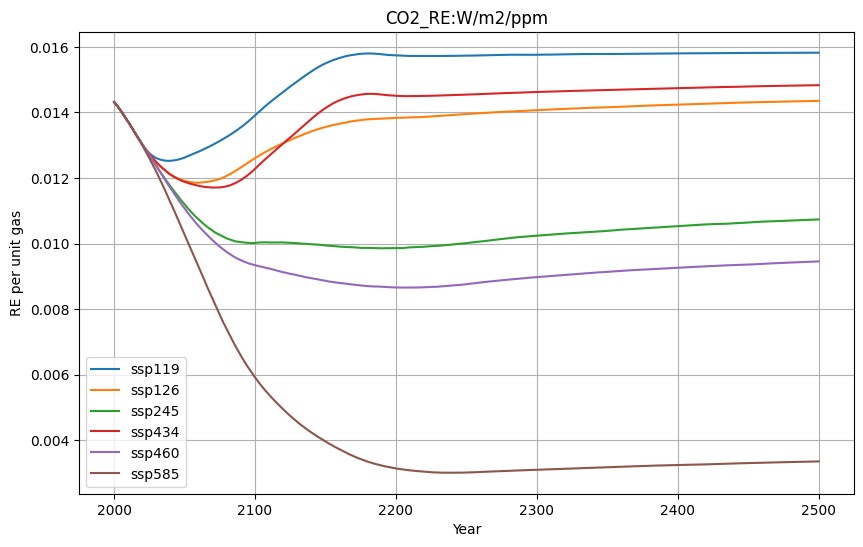

In [27]:
figco2, figco2_html, reco2, co2_c, co2_lifetime, co2_all_ensemble_dict = get_gas_single_RE_year_ssp(["ssp119", "ssp126", "ssp245", "ssp434", "ssp460", "ssp585"], "CO2")

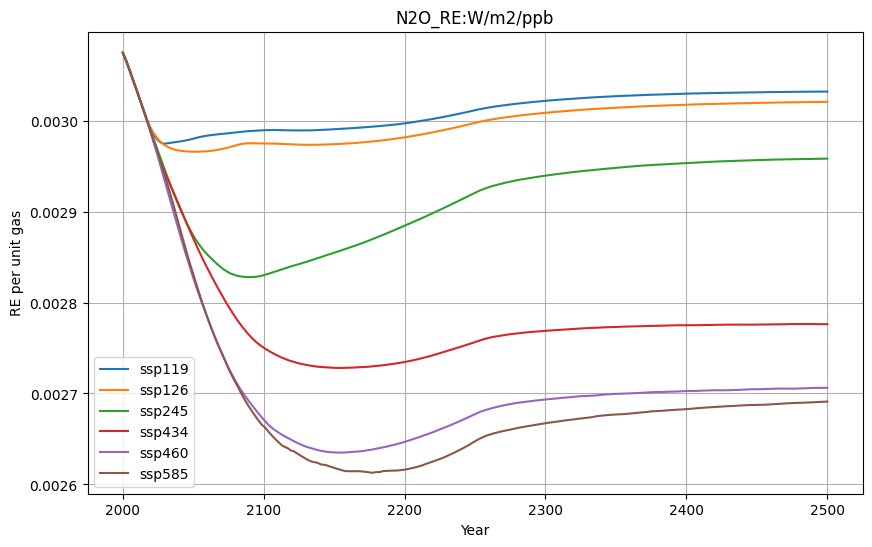

In [28]:
fign2o, fign2o_html, ren2o, n2o_c, n2o_lifetime, n2o_all_ensemble_dict =  get_gas_single_RE_year_ssp(["ssp119", "ssp126", "ssp245", "ssp434", "ssp460", "ssp585"], "N2O")

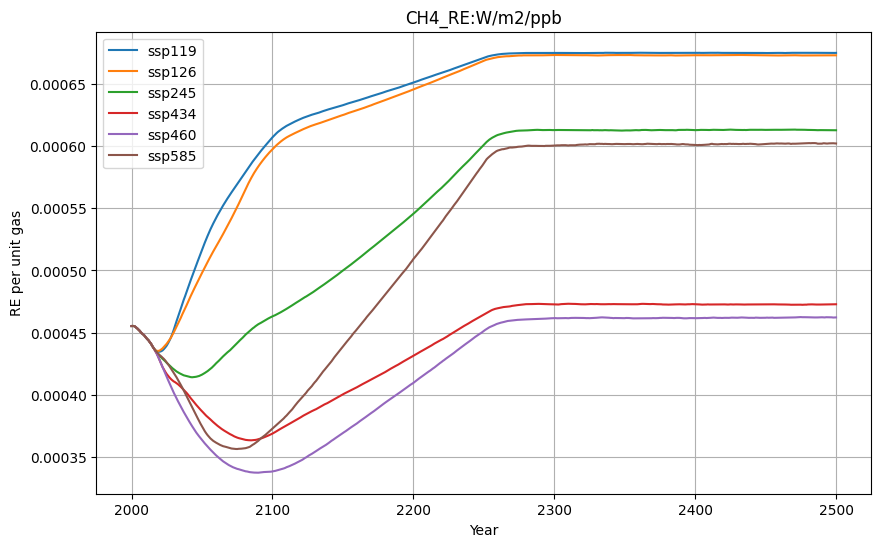

In [29]:
figch4, figch4_html, rech4, ch4_c, ch4_lifetime, ch4_all_ensemble_dict =  get_gas_single_RE_year_ssp(["ssp119", "ssp126", "ssp245", "ssp434", "ssp460", "ssp585"], "CH4")


#### to get / save HTML 

### saving all the newly prepared new DFs, and 1001 ensembles dict as pickle: 

In [30]:
ren2o.shape

(501, 6)

In [31]:
co2_c.head()

,ssp119,ssp126,ssp245,ssp434,ssp460,ssp585
2000,368.853189,368.853189,368.853189,368.853189,368.853189,368.853189
2001,370.454563,370.454563,370.454563,370.454563,370.454563,370.454563
2002,372.020251,372.020251,372.020251,372.020251,372.020251,372.020251
2003,373.699603,373.699603,373.699603,373.699603,373.699603,373.699603
2004,375.436046,375.436046,375.436046,375.436046,375.436046,375.436046


In [32]:
ch4_lifetime.head()

,CH4_lifetime_median
ssp119,10.193618
ssp126,10.199870
ssp245,10.448021
ssp434,10.443744
ssp460,10.443744


In [33]:
import os
import pickle
 
Y_START = 2000
def set_year_index(df: pd.DataFrame, y_start: int = Y_START) -> pd.DataFrame:
    """Convert RangeIndex 0..N-1 (or numeric) into calendar years y_start.."""
    df = df.copy()
    n = len(df)
    df.index = np.arange(y_start, y_start + n)
    df.index.name = "Year"
    return df

In [34]:
reco2 = set_year_index(reco2)
co2_c = set_year_index(co2_c)

rech4 = set_year_index(rech4)
ch4_c = set_year_index(ch4_c)

ren2o = set_year_index(ren2o)
n2o_c = set_year_index(n2o_c)


In [35]:
# --- save all DFs in one Excel workbook ---
out_dir = "output/parameters_C_ERF_lifetime"

xlsx_path = os.path.join(out_dir, "ERF_C_lifetime_CO2CH4N2O_2000_2500_run2026-02-24.xlsx")

with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    reco2.to_excel(writer, sheet_name="CO2_RE", index=True)
    co2_c.to_excel(writer, sheet_name="CO2_C", index=True)
    # co2_lifetime is NaN not runned from fair

    rech4.to_excel(writer, sheet_name="CH4_RE", index=True)
    ch4_c.to_excel(writer, sheet_name="CH4_C", index=True)
    ch4_lifetime.to_excel(writer, sheet_name="CH4_alpha", index=True)

    ren2o.to_excel(writer, sheet_name="RE_N2O", index=True)
    n2o_c.to_excel(writer, sheet_name="N2O_C", index=True)
    n2o_lifetime.to_excel(writer, sheet_name="N2O_alpha", index=True)

In [36]:
# save the 1001-ensemble dicts as pickle
pkl_path = os.path.join(out_dir, "ERF_C_lifetime_CO2CH4N2O_1001ensemble_dicts_run2026-02-24.pkl")

payload = {
    "co2_all_ensemble_dict": co2_all_ensemble_dict,
    "ch4_all_ensemble_dict": ch4_all_ensemble_dict,
    "n2o_all_ensemble_dict": n2o_all_ensemble_dict,
}
#most recent binary serialization format supported by current Python: protocol=5 (Python ≥3.8)  most efficient for large NumPy
with open(pkl_path, "wb") as ffff:
    pickle.dump(payload, ffff, protocol=pickle.HIGHEST_PROTOCOL)
    pickle.dump(payload, ffff, protocol=pickle.HIGHEST_PROTOCOL)

# just run here:  new StepB  for decay side  :   rerun fair dynamically, to get pertubed output for each year: 


In [23]:
from __future__ import annotations

import copy
from typing import Dict, Tuple, Union

import numpy as np


def _as_float_array(x) -> np.ndarray:
    return np.asarray(x, dtype=float)


def _find_index_near(arr: Union[np.ndarray, list], target: float, tol: float = 1e-6) -> int:
    a = _as_float_array(arr)
    i = int(np.argmin(np.abs(a - float(target))))
    if abs(a[i] - float(target)) > tol:
        raise ValueError(f"Target={target} not found within tol={tol}. Closest={a[i]} at i={i}.")
    return i


def _find_index_exact_year(arr: Union[np.ndarray, list], year_int: int) -> int:
    a = _as_float_array(arr)
    hits = np.where(a == float(int(year_int)))[0]
    if hits.size == 0:
        raise ValueError(f"Year {year_int} not found in axis.")
    return int(hits[0])


def _first_index_ge(arr: Union[np.ndarray, list], target: float) -> int:
    a = _as_float_array(arr)
    hits = np.where(a >= float(target))[0]
    if hits.size == 0:
        raise ValueError(f"Target {target} beyond axis max {a.max()}.")
    return int(hits[0])


class majorghg_get_f:
    """
    FaIR pIRF calculator
    Uses full deepcopy for both baseline and perturbed to prevent FaIR state bleed-through.
    """

    def __init__(
        self,
        f,
        scn: str,
        H_max: int = 100,
        ts_per_year: int = 1,
        year_index: int = 269,
        debug: bool = False,
    ):
        self.f = f
        self.scn = str(scn)
        self.H_max = int(H_max)
        self.ts_per_year = int(ts_per_year)
        self.year_index = int(year_index)
        self.debug = bool(debug)

        self.H = np.linspace(0, self.H_max, self.H_max * self.ts_per_year + 1)

        # Optional storage
        self.co2_f = {"CO2_dC_ppm_t": None, "CO2_IRF_fair_t": None}
        self.ch4_f = {"CH4_dC_ppb_t": None, "CH4_IRF_fair_t": None}
        self.n2o_f = {"N2O_dC_ppb_t": None, "N2O_IRF_fair_t": None}

    # -------------------------
    # time helpers
    # -------------------------
    def _get_pulse_year(self) -> int:
        tb = _as_float_array(self.f.timebounds)
        return int(tb[int(self.year_index)])

    def _get_timebound_index(self, pulse_year: int) -> int:
        return _find_index_exact_year(self.f.timebounds, pulse_year)

    def _get_timepoint_index(self, pulse_year: int) -> int:
        dt = 1.0 / float(self.ts_per_year)
        target_tp = float(pulse_year) + 0.5 * dt
        return _find_index_near(self.f.timepoints, target_tp, tol=1e-4)

    # -------------------------
    # core ΔC and IRF
    # -------------------------
    def get_gas_deltaC_t(
        self,
        specie_conc: str,
        specie_emis: Union[str, Tuple[str, ...]],
        pulse_size: float = 1.0,
        pulse_split: str = "equal",     # "equal" or "none"
        pre_window_years: int = 20,
        eps_prepulse: float = 1e-3,
        store: bool = True,
    ) -> np.ndarray:
        """
        Baseline/perturbed computed from two independent deepcopies of self.f:
          f_base = deepcopy(self.f); run
          f_pert = deepcopy(self.f); pulse; run
        ΔC = conc_pert - conc_base (same scenario/specie)
        Enforces pre-pulse ΔC ~ 0.
        """

        # normalize emissions species
        if isinstance(specie_emis, str):
            emis_species = (specie_emis,)
        else:
            emis_species = tuple(specie_emis)

        if pulse_split not in ("equal", "none"):
            raise ValueError("pulse_split must be 'equal' or 'none'.")

        if pulse_split == "equal":
            pulse_parts = [float(pulse_size) / float(len(emis_species))] * len(emis_species)
        else:
            pulse_parts = [float(pulse_size)] * len(emis_species)

        # indices based on self.f axes
        pulse_year = self._get_pulse_year()
        tb_pulse = self._get_timebound_index(pulse_year)
        tp_pulse = self._get_timepoint_index(pulse_year)

        dt = 1.0 / float(self.ts_per_year)
        tp_axis_self = _as_float_array(self.f.timepoints)
        tb_axis_self = _as_float_array(self.f.timebounds)
        tp_pulse_time = float(tp_axis_self[tp_pulse])

        # response starts at first timebound >= tp_pulse_time + dt
        tb_resp0 = _first_index_ge(tb_axis_self, tp_pulse_time + dt - 1e-12)

        nH = self.H_max * self.ts_per_year + 1
        tb1 = tb_resp0 + nH
        if tb1 > tb_axis_self.size:
            raise ValueError(f"Horizon exceeds timebounds: tb_resp0={tb_resp0}, nH={nH}, tb1={tb1}, avail={tb_axis_self.size}")

        # ---- baseline run (independent) ----
        f_base = copy.deepcopy(self.f)
        f_base.run()
        conc_base = np.asarray(
            f_base.concentration.loc[dict(scenario=self.scn, specie=specie_conc)].values
        ).copy()

        # ---- perturbed run (independent) ----
        f_pert = copy.deepcopy(self.f)

        sanity_before_after = []
        for sp_e, p_add in zip(emis_species, pulse_parts):
            em_slice = f_pert.emissions.loc[dict(scenario=self.scn, specie=sp_e)].copy()
            em_vals = np.asarray(em_slice.values)

            if em_vals.ndim == 1:
                before = float(em_vals[tp_pulse])
                em_vals[tp_pulse] = before + p_add
                after = float(em_vals[tp_pulse])
            else:
                before = float(np.nanmedian(em_vals[tp_pulse, ...]))
                em_vals[tp_pulse, ...] = em_vals[tp_pulse, ...] + p_add
                after = float(np.nanmedian(em_vals[tp_pulse, ...]))

            em_slice.values = em_vals
            f_pert.emissions.loc[dict(scenario=self.scn, specie=sp_e)] = em_slice
            sanity_before_after.append((sp_e, before, after, p_add))

        if self.debug:
            tb_axis = _as_float_array(f_base.timebounds)
            tp_axis = _as_float_array(f_base.timepoints)
            print(
                f"[pIRF-base] scn={self.scn} year_index={self.year_index} pulse_year={pulse_year} "
                f"tb_pulse={tb_pulse}(tb={tb_axis[tb_pulse]:.1f}) tp_pulse={tp_pulse}(tp={tp_axis[tp_pulse]:.3f})"
            )
            print(
                f"[pIRF-debug] scn={self.scn} year_index={self.year_index} pulse_year={pulse_year} "
                f"gas={specie_conc} emis={','.join(emis_species)} "
                f"tb_pulse={tb_pulse}(tb={tb_axis[tb_pulse]:.1f}) tp_pulse={tp_pulse}(tp={tp_axis[tp_pulse]:.3f}) "
                f"dt={dt:g} tb_resp0={tb_resp0}(tb={tb_axis[tb_resp0]:.1f})"
            )
            for (sp_e, b0, b1, p_add) in sanity_before_after:
                print(f"[SANITY] {sp_e} emis@tp_pulse median before/after: {b0:.6g} -> {b1:.6g} (add {p_add:.6g})")

        f_pert.run()
        conc_pert = np.asarray(
            f_pert.concentration.loc[dict(scenario=self.scn, specie=specie_conc)].values
        ).copy()

        if conc_pert.shape != conc_base.shape:
            raise RuntimeError(f"Shape mismatch: base={conc_base.shape}, pert={conc_pert.shape}")

        dC = conc_pert - conc_base

        # pre-pulse mismatch check
        pre0 = max(tb_pulse - int(pre_window_years * self.ts_per_year), 0)
        pre_slice = dC[pre0:tb_pulse, ...]
        pre_med = float(np.nanmedian(pre_slice)) if pre_slice.size else 0.0
        pre_max = float(np.nanmax(np.abs(pre_slice))) if pre_slice.size else 0.0
        full_max = float(np.nanmax(np.abs(dC)))

        if self.debug:
            print(f"[SANITY-ΔC] pre-pulse median={pre_med:.6g}, pre-pulse maxabs={pre_max:.6g}, full maxabs={full_max:.6g}")

        if pre_max > float(eps_prepulse):
            raise RuntimeError(
                "Baseline mismatch detected: ΔC is not ~0 before pulse.\n"
                f"pre_window_years={pre_window_years}, pre_maxabs={pre_max:.6g} (thresh {eps_prepulse:.6g}), pre_median={pre_med:.6g}\n"
                "This indicates baseline/perturbed are not consistent (scenario selection/run state mismatch)."
            )

        dC_h = dC[tb_resp0:tb1, ...].copy()

        if self.debug:
            dC0_med = float(np.nanmedian(dC_h[0, ...]))
            dCend_med = float(np.nanmedian(dC_h[-1, ...]))
            print(f"[SANITY] {specie_conc} ΔC_h median: ΔC0={dC0_med:.6g} ΔCend(H={self.H_max})={dCend_med:.6g}")

        if store:
            if specie_conc == "CO2":
                self.co2_f["CO2_dC_ppm_t"] = dC_h
            elif specie_conc == "CH4":
                self.ch4_f["CH4_dC_ppb_t"] = dC_h
            elif specie_conc == "N2O":
                self.n2o_f["N2O_dC_ppb_t"] = dC_h

        return dC_h

    def get_gas_IRF_fair_t(
        self,
        specie_conc: str,
        specie_emis: Union[str, Tuple[str, ...]],
        pulse_size: float = 1.0,
        pulse_split: str = "equal",
        eps: float = 1e-18,
        store: bool = True,
    ) -> np.ndarray:
        dC_h = self.get_gas_deltaC_t(
            specie_conc=specie_conc,
            specie_emis=specie_emis,
            pulse_size=pulse_size,
            pulse_split=pulse_split,
            store=store,
        )

        dC0 = np.asarray(dC_h[0, ...])
        small = np.abs(dC0) < eps
        if np.any(small):
            n_bad = int(np.sum(small))
            print(f"[WARNING] {specie_conc} pIRF: {n_bad} member(s) have |ΔC0|<{eps:.1e}; using eps.")

        dC0_safe = np.where(small, eps, dC0)
        irf_h = dC_h / dC0_safe
        irf_h[0, ...] = 1.0

        if store:
            if specie_conc == "CO2":
                self.co2_f["CO2_IRF_fair_t"] = irf_h
            elif specie_conc == "CH4":
                self.ch4_f["CH4_IRF_fair_t"] = irf_h
            elif specie_conc == "N2O":
                self.n2o_f["N2O_IRF_fair_t"] = irf_h

        return irf_h

    # wrappers
    def get_co2_pIRF(
        self,
        pulse_size: float = 1.0,
        co2_emis: Tuple[str, ...] = ("CO2 FFI",),
        pulse_split: str = "equal",
    ):
        return self.get_gas_IRF_fair_t(
            specie_conc="CO2",
            specie_emis=co2_emis,
            pulse_size=pulse_size,
            pulse_split=pulse_split,
            store=True,
        )

    def get_ch4_pIRF(self, pulse_size: float = 1.0):
        return self.get_gas_IRF_fair_t("CH4", "CH4", pulse_size=pulse_size, pulse_split="equal", store=True)

    def get_n2o_pIRF(self, pulse_size: float = 1.0):
        return self.get_gas_IRF_fair_t("N2O", "N2O", pulse_size=pulse_size, pulse_split="equal", store=True)


def majorghg_get_irf(
    f,
    scn: str,
    H_max: int = 100,
    ts_per_year: int = 1,
    year_index: int = 269,
    debug: bool = False,
):
    return majorghg_get_f(
        f=f,
        scn=scn,
        H_max=H_max,
        ts_per_year=ts_per_year,
        year_index=year_index,
        debug=debug,
    )

In [24]:


H_MAX = 100
f36 = majorghg_get_irf(
    f=f,
    scn="ssp245",
    H_max=H_MAX,
    ts_per_year=1,
    year_index=280,
    debug=True,
)


In [26]:

# safest while debugging:
pirf_co2_full = f36.get_co2_pIRF(
    pulse_size=1.0,
    co2_emis=("CO2 FFI",),
    pulse_split="equal",
    
)

Running 7007 projections in parallel: 100%|█| 750/750 [03:10<00:00,  3.93timeste


[pIRF-base] scn=ssp245 year_index=280 pulse_year=2030 tb_pulse=280(tb=2030.0) tp_pulse=280(tp=2030.500)
[pIRF-debug] scn=ssp245 year_index=280 pulse_year=2030 gas=CO2 emis=CO2 FFI tb_pulse=280(tb=2030.0) tp_pulse=280(tp=2030.500) dt=1 tb_resp0=282(tb=2032.0)
[SANITY] CO2 FFI emis@tp_pulse median before/after: 40.5947 -> 41.5947 (add 1)


Running 7007 projections in parallel: 100%|█| 750/750 [03:30<00:00,  3.56timeste


[SANITY-ΔC] pre-pulse median=0, pre-pulse maxabs=0, full maxabs=0.12307
[SANITY] CO2 ΔC_h median: ΔC0=0.107654 ΔCend(H=100)=0.0658075


In [27]:
H_MAX_LIST = [5, 10, 20, 30, 40, 50, 60, 80, 100]
for H_test in H_MAX_LIST:
    print(H_test, float(np.nanmedian(pirf_co2_full[H_test])))

5 0.7959977623126734
10 0.7399837199666321
20 0.6892616418830158
30 0.6655374819725672
40 0.652706615677944
50 0.6447352852480144
60 0.6370772833714742
80 0.6221106129030695
100 0.6114929807464454


5 0.7959977623126734
10 0.7399837199666321
20 0.6892616418830158
30 0.6655374819725672
40 0.652706615677944
50 0.6447352852480144
60 0.6370772833714742
80 0.6221106129030695
100 0.6114929807464454


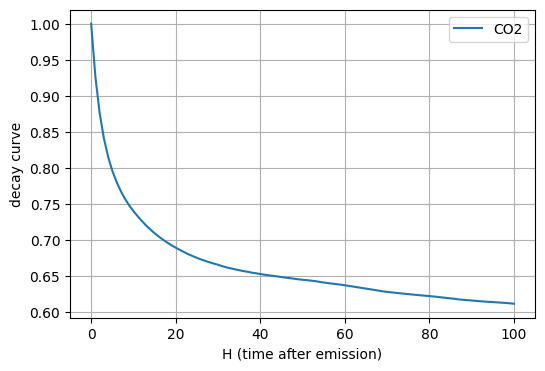

In [29]:
import numpy as np

H_MAX_LIST = [5, 10, 20, 30, 40, 50, 60, 80, 100]

for H_test in H_MAX_LIST:
    print(H_test, np.nanmedian(pirf_co2_full[H_test]))
    
    
    
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(f36.H, np.nanmedian(pirf_co2_full, axis=tuple(range(1,pirf_co2_full.ndim))), label="CO2")
plt.xlabel("H (time after emission)")
plt.ylabel("decay curve")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# for different model year, need rerun as basline is cached: 

f40 = majorghg_get_irf(
    f=f,
    scn="ssp245",
    H_max=100,
    ts_per_year=1,
    year_index=300,
    debug=True,
)

pirf_co2_2050 = f40.get_co2_pIRF()

# fix in v3.2 use FULL deepcopy for BOTH baseline and perturbed (most robust)

 